In [1]:
# 1. Imports

from pathlib import Path

import torch
from dataset import (
    ChessPolicyDataset,
    build_training_examples,
    split_game_records,
)
from datasets import load_dataset
from model import PolicyCNN
from model_artifacts import (
    build_model_metadata_payload,
    export_onnx_model,
    load_safetensors_checkpoint,
    save_safetensors_checkpoint,
    write_model_metadata,
)
from torch import nn
from torch.utils.data import DataLoader
from training import (
    evaluate,
    train_one_epoch,
)

In [2]:
# 2. Experiment configuration


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists() and (
            candidate / "artifacts"
        ).exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root")


REPO_ROOT = find_repo_root()

DATASET_NAME = "Lichess/standard-chess-games"

MIN_ELO = 1800
SAMPLE_SIZE = 10_000

VALIDATION_FRACTION = 0.2
SEED = 42

BATCH_SIZE = 256
LEARNING_RATE = 1e-3
EPOCHS = 10

MODEL_PATH_SAFETENSORS = REPO_ROOT / "artifacts" / "notebook" / "policy_v1.safetensors"
MODEL_PATH_ONNX = REPO_ROOT / "artifacts" / "notebook" / "policy_v1.onnx"
MODEL_PATH_METADATA = REPO_ROOT / "artifacts" / "notebook" / "policy_v1.json"

In [3]:
# 3. Device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cuda')

In [4]:
# 4. Load Lichess games

games = load_dataset(
    DATASET_NAME,
    split="train",
    streaming=True,
)

filtered_games = games.filter(
    lambda game: (
        game["WhiteElo"] is not None
        and game["BlackElo"] is not None
        and game["WhiteElo"] >= MIN_ELO
        and game["BlackElo"] >= MIN_ELO
        and game["Result"]
        in {
            "1-0",
            "0-1",
            "1/2-1/2",
        }
    )
)

game_records = list(filtered_games.take(SAMPLE_SIZE))

print(f"Games validated: {len(game_records):,}")

Resolving data files:   0%|          | 0/26138 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/26138 [00:00<?, ?it/s]

Games validated: 10,000


In [5]:
print(type(game_records))
print(game_records[:1])

<class 'list'>
[{'Event': 'Rated Bullet game', 'Site': 'https://lichess.org/rklpc7mk', 'White': 'Naitero_Nagasaki', 'Black': '800', 'Result': '0-1', 'WhiteTitle': None, 'BlackTitle': None, 'WhiteElo': 1824, 'BlackElo': 1973, 'WhiteRatingDiff': -6, 'BlackRatingDiff': 8, 'UTCDate': datetime.date(2012, 12, 31), 'UTCTime': datetime.time(23, 4, 57), 'ECO': 'B12', 'Opening': 'Caro-Kann Defense: Goldman Variation', 'Termination': 'Normal', 'TimeControl': '60+1', 'movetext': '1. e4 c6 2. Nc3 d5 3. Qf3 dxe4 4. Nxe4 Nd7 5. Bc4 Ngf6 6. Nxf6+ Nxf6 7. Qg3 Bf5 8. d3 Bg6 9. Ne2 e6 10. Bf4 Nh5 11. Qf3 Nxf4 12. Nxf4 Be7 13. Bxe6 fxe6 14. Nxe6 Qa5+ 15. c3 Qe5+ 16. Qe3 Qxe3+ 17. fxe3 Kd7 18. Nf4 Bd6 19. Nxg6 hxg6 20. h3 Bg3+ 21. Kd2 Raf8 22. Rhf1 Ke7 23. d4 Rxf1 24. Rxf1 Rf8 25. Rxf8 Kxf8 26. e4 Ke7 27. Ke3 g5 28. Kf3 Be1 29. Kg4 Bd2 30. Kf5 Bc1 31. Kg6 Kf8 32. e5 Bxb2 33. Kxg5 Bxc3 34. h4 Bxd4 35. h5 Bxe5 36. g4 Bb2 37. Kf5 Kf7 38. g5 Bc1 39. g6+ Ke7 40. Ke5 b5 41. Kd4 Kd6 42. Kc3 c5 43. a3 Bg5 44. a4 b

In [6]:
# 5. Game-level train/validation split

training_records, validation_records = split_game_records(
    game_records,
    validation_fraction=VALIDATION_FRACTION,
    seed=SEED,
)

len(training_records), len(validation_records)

(8000, 2000)

In [7]:
# 6. Build training observations

training_examples = build_training_examples(training_records)

validation_examples = build_training_examples(validation_records)

len(training_examples), len(validation_examples)

(609081, 153604)

In [8]:
print(f"training_examples type: {type(training_examples)}")
print(f"training_examples[0] type: {type(training_examples[0])}")
print(f"training_examples[1] type: {type(training_examples[1])}")
print(training_examples[0])
print(training_examples[1])

training_examples type: <class 'list'>
training_examples[0] type: <class 'dataset.TrainingExample'>
training_examples[1] type: <class 'dataset.TrainingExample'>
TrainingExample(board=Board('rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1'), move=Move.from_uci('e2e4'), source_game_id='https://lichess.org/lms7zj7w', ply=1, white_elo=2090, black_elo=1967)
TrainingExample(board=Board('rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1'), move=Move.from_uci('e7e5'), source_game_id='https://lichess.org/lms7zj7w', ply=2, white_elo=2090, black_elo=1967)


In [9]:
# 7. PyTorch datasets

training_dataset = ChessPolicyDataset(training_examples)

validation_dataset = ChessPolicyDataset(validation_examples)

print(f"training_dataset type: {type(training_dataset)}")
print(f"validation_dataset type: {type(validation_dataset)}")
print(f"training_dataset length: {len(training_dataset)}")
print(f"validation_dataset length: {len(validation_dataset)}")

training_dataset type: <class 'dataset.ChessPolicyDataset'>
validation_dataset type: <class 'dataset.ChessPolicyDataset'>
training_dataset length: 609081
validation_dataset length: 153604


In [10]:
print(type(training_dataset))

x, y = training_dataset[0]

print(f"x: {x}")
print(f"y: {y}")

<class 'dataset.ChessPolicyDataset'>
x: tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 1., 0.,  ..., 0., 1., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 1.,  ..., 1., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  

In [11]:
# 8. DataLoaders

training_loader = DataLoader(
    training_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [12]:
x, y = next(iter(training_loader))

print("X:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)

X: torch.Size([256, 18, 8, 8]) torch.float32
y: torch.Size([256]) torch.int64


In [13]:
# 9. Model, loss, optimizer

model = PolicyCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

In [14]:
parameter_count = sum(parameter.numel() for parameter in model.parameters())

trainable_parameter_count = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad
)

print(f"Parameters: {parameter_count:,}")
print(f"Trainable parameters: {trainable_parameter_count:,}")

Parameters: 6,372,832
Trainable parameters: 6,372,832


In [15]:
# 10. Train and validate

history = []

best_validation_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    training_metrics = train_one_epoch(
        model=model,
        dataloader=training_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )

    validation_metrics = evaluate(
        model=model,
        dataloader=validation_loader,
        dataset=validation_dataset,
        criterion=criterion,
        device=device,
    )

    history.append(
        {
            "epoch": epoch,
            "train_loss": training_metrics.loss,
            "train_top1": training_metrics.top1_accuracy,
            "train_top3": training_metrics.top3_accuracy,
            "train_top5": training_metrics.top5_accuracy,
            "validation_loss": validation_metrics.loss,
            "validation_top1": validation_metrics.top1_accuracy,
            "validation_top3": validation_metrics.top3_accuracy,
            "validation_top5": validation_metrics.top5_accuracy,
            "validation_illegal_top1": (validation_metrics.illegal_top1_rate),
        }
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train loss={training_metrics.loss:.4f} | "
        f"val loss={validation_metrics.loss:.4f} | "
        f"top1={validation_metrics.top1_accuracy:.3%} | "
        f"top3={validation_metrics.top3_accuracy:.3%} | "
        f"top5={validation_metrics.top5_accuracy:.3%} | "
        f"illegal={validation_metrics.illegal_top1_rate:.3%}"
    )

    if validation_metrics.loss < best_validation_loss:
        best_validation_loss = validation_metrics.loss

        save_safetensors_checkpoint(
            model,
            MODEL_PATH_SAFETENSORS,
        )

Epoch 01 | train loss=4.7716 | val loss=3.6001 | top1=19.248% | top3=36.542% | top5=46.056% | illegal=17.951%
Epoch 02 | train loss=3.2063 | val loss=3.0894 | top1=24.272% | top3=44.014% | top5=54.502% | illegal=10.625%
Epoch 03 | train loss=2.8347 | val loss=2.9400 | top1=26.600% | top3=47.493% | top5=57.992% | illegal=8.711%
Epoch 04 | train loss=2.6470 | val loss=2.8867 | top1=27.553% | top3=48.900% | top5=59.598% | illegal=8.306%
Epoch 05 | train loss=2.5211 | val loss=2.8466 | top1=28.608% | top3=50.336% | top5=61.023% | illegal=8.127%
Epoch 06 | train loss=2.4251 | val loss=2.8409 | top1=28.779% | top3=50.626% | top5=61.184% | illegal=7.958%
Epoch 07 | train loss=2.3493 | val loss=2.8490 | top1=28.818% | top3=50.981% | top5=61.763% | illegal=7.890%
Epoch 08 | train loss=2.2859 | val loss=2.8626 | top1=29.127% | top3=51.273% | top5=62.056% | illegal=7.637%
Epoch 09 | train loss=2.2302 | val loss=2.8694 | top1=29.217% | top3=51.374% | top5=61.979% | illegal=7.553%
Epoch 10 | train 

In [16]:
# Export safetensor to ONNX format
# 11. Export best model to ONNX

best_model = PolicyCNN()

load_safetensors_checkpoint(
    best_model,
    MODEL_PATH_SAFETENSORS,
)

export_onnx_model(
    best_model,
    MODEL_PATH_ONNX,
    opset_version=18,
)

print(f"Exported ONNX model to {MODEL_PATH_ONNX}")

/mnt/c/working/public/chess-multiplayer/apps/trainer/model_artifacts.py:228: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0915 15:46:16.398000 15574 torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::nms
W0915 15:46:16.403000 15574 torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::roi_align
W0915 15:46:16.404000 15574 torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::roi_pool
W0915 15:46:16.406000 15574 torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::deform_conv2d


[torch.onnx] Obtain model graph for `PolicyCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `PolicyCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Exported ONNX model to /mnt/c/working/public/chess-multiplayer/artifacts/notebook/policy_v1.onnx


In [17]:
write_model_metadata(
    MODEL_PATH_METADATA,
    build_model_metadata_payload(
        onnx_opset=18,
        extra_fields={
            "artifact_stem": "policy_v1",
            "artifact_paths": {
                "safetensors": MODEL_PATH_SAFETENSORS.name,
                "onnx": MODEL_PATH_ONNX.name,
                "metadata": MODEL_PATH_METADATA.name,
            },
            "training_examples": len(training_examples),
            "validation_examples": len(validation_examples),
            "best_validation_loss": best_validation_loss,
        },
    ),
)

In [18]:
# 11. Metrics table

import pandas as pd

history_df = pd.DataFrame(history)

history_df

,epoch,train_loss,train_top1,train_top3,train_top5,validation_loss,validation_top1,validation_top3,validation_top5,validation_illegal_top1
0,1,4.771635,0.119038,0.231055,0.297478,3.600070,0.192475,0.365420,0.460561,0.179507
1,2,3.206298,0.229753,0.423435,0.526779,3.089376,0.242715,0.440138,0.545018,0.106254
2,3,2.834663,0.275103,0.491130,0.601014,2.939967,0.265996,0.474929,0.579920,0.087114
3,4,2.646984,0.304204,0.533041,0.643614,2.886716,0.275527,0.489004,0.595981,0.083064
4,5,2.521147,0.326144,0.562438,0.673112,2.846632,0.286080,0.503359,0.610232,0.081274
5,6,2.425120,0.343687,0.585129,0.695832,2.840941,0.287785,0.506256,0.611840,0.079581
6,7,2.349278,0.358235,0.603591,0.713360,2.849027,0.288176,0.509811,0.617627,0.078904
7,8,2.285873,0.371131,0.619359,0.728553,2.862596,0.291275,0.512734,0.620557,0.076372
8,9,2.230179,0.382227,0.632395,0.740654,2.869362,0.292173,0.513743,0.619789,0.075525
9,10,2.181572,0.392529,0.644185,0.751153,2.907100,0.293104,0.513392,0.619854,0.076131


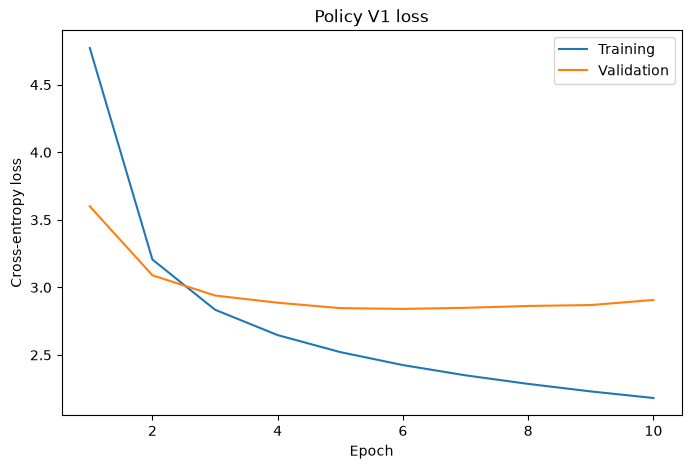

In [19]:
# 12. Loss curves

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training",
)

plt.plot(
    history_df["epoch"],
    history_df["validation_loss"],
    label="Validation",
)

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Policy V1 loss")
plt.legend()
plt.show()

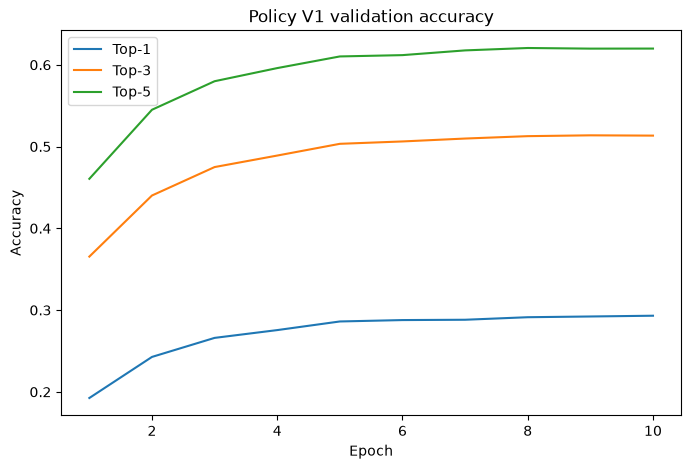

In [20]:
# 13. Validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["validation_top1"],
    label="Top-1",
)

plt.plot(
    history_df["epoch"],
    history_df["validation_top3"],
    label="Top-3",
)

plt.plot(
    history_df["epoch"],
    history_df["validation_top5"],
    label="Top-5",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Policy V1 validation accuracy")
plt.legend()
plt.show()

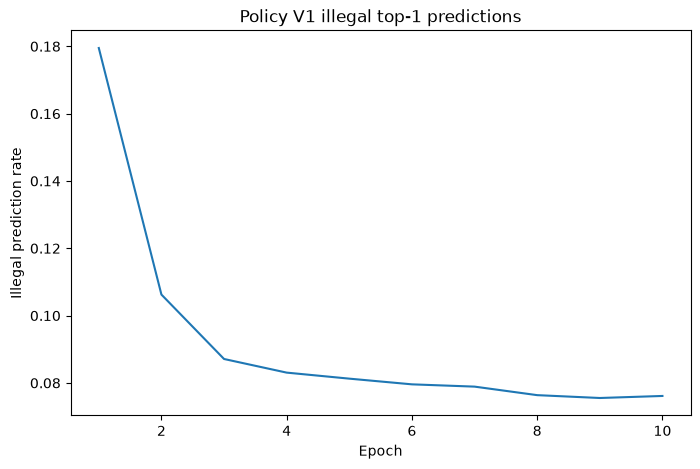

In [21]:
# 14. Illegal top-1 prediction rate

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["validation_illegal_top1"],
)

plt.xlabel("Epoch")
plt.ylabel("Illegal prediction rate")
plt.title("Policy V1 illegal top-1 predictions")
plt.show()

In [22]:
# 15. Best validation result

best_epoch = history_df.loc[history_df["validation_loss"].idxmin()]

best_epoch

epoch                      6.000000
train_loss                 2.425120
train_top1                 0.343687
train_top3                 0.585129
train_top5                 0.695832
validation_loss            2.840941
validation_top1            0.287785
validation_top3            0.506256
validation_top5            0.611840
validation_illegal_top1    0.079581
Name: 5, dtype: float64

V1 Baseline

```
V1 Policy CNN
────────────────────────────────

Training games:       10,000
Minimum Elo:          1800
Split:                80/20 by game
Batch size:           256
Epochs:               10
Parameters:           6,372,832
Training time:        ~16 min

Best val loss:        2.8516 (epoch 7)

Final observed:
Top-1:                29.09%
Top-3:                51.10%
Top-5:                61.63%
Illegal top-1:         7.71%
```